# Employee Burnout & Attrition Predictor

### Import necessary libraries and load dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc)
from imblearn.over_sampling import SMOTE
import warnings

In [ ]:
df = pd.read_csv("ai_worker_burnout_attrition_2026.csv")

In [ ]:
df.head()

,employee_id,job_role,years_experience,education_level,country,industry,company_size,remote_work_type,team_size,salary_usd_k,...,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,ai_adoption_stage,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5,fear_of_ai_replacement,attrition_risk
0,EMP0001,Data Analyst,7,PhD,India,Healthtech,Large (1000-5000),Fully Remote,8,184,...,1,0.6,37,Experimenting,4.9,59,58,3.0,Low,Medium
1,EMP0002,DevOps Engineer,3,Self-taught,Canada,Fintech,Large (1000-5000),Hybrid,42,51,...,3,0.6,78,Experimenting,6.6,64,47,3.6,Medium,Medium
2,EMP0003,Prompt Engineer,3,PhD,India,Automotive,Startup (<50),Hybrid,37,185,...,4,4.0,23,Optimizing,5.8,50,37,4.6,High,Medium
3,EMP0004,Backend Engineer,18,Master,Germany,Media,Mid (200-1000),Fully Remote,8,131,...,5,4.2,75,Integrating,1.4,77,67,3.0,Low,Medium
4,EMP0005,AI Researcher,5,Bachelor,India,E-commerce,Small (50-200),Fully Remote,21,99,...,7,0.7,61,Experimenting,1.6,58,54,3.6,Medium,Medium


In [ ]:
print("Rows & Columns:", df.shape)

Rows & Columns: (1500, 21)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   employee_id                     1500 non-null   object 
 1   job_role                        1500 non-null   object 
 2   years_experience                1500 non-null   int64  
 3   education_level                 1500 non-null   object 
 4   country                         1500 non-null   object 
 5   industry                        1500 non-null   object 
 6   company_size                    1500 non-null   object 
 7   remote_work_type                1500 non-null   object 
 8   team_size                       1500 non-null   int64  
 9   salary_usd_k                    1500 non-null   int64  
 10  primary_ai_tool                 1500 non-null   object 
 11  ai_tools_used_per_day           1500 non-null   int64  
 12  hours_with_ai_assistance_daily  15

In [ ]:
df.isnull().sum()

,0
employee_id,0
job_role,0
years_experience,0
education_level,0
country,0
industry,0
company_size,0
remote_work_type,0
team_size,0
salary_usd_k,0


In [ ]:
df.describe()

,years_experience,team_size,salary_usd_k,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5
count,1500.000000,1500.000000,1500.000000,1500.00000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,9.947333,24.812667,140.734000,4.05600,4.233733,41.248667,4.985533,57.543333,50.057333,3.334733
std,5.460932,13.682582,59.717429,1.97403,2.148387,21.658214,2.913933,10.726952,11.437771,0.636692
min,1.000000,2.000000,40.000000,1.00000,0.500000,5.000000,0.000000,25.000000,16.000000,1.300000
25%,5.000000,13.000000,91.000000,2.00000,2.400000,22.750000,2.400000,50.000000,42.000000,2.900000
50%,10.000000,25.000000,139.000000,4.00000,4.200000,40.000000,5.000000,57.000000,50.000000,3.300000
75%,15.000000,36.000000,190.000000,6.00000,6.100000,60.000000,7.500000,65.000000,58.000000,3.800000
max,19.000000,49.000000,249.000000,7.00000,8.000000,79.000000,10.000000,95.000000,86.000000,5.000000


In [ ]:
print('Columns :', df.columns)

Columns : Index(['employee_id', 'job_role', 'years_experience', 'education_level',
       'country', 'industry', 'company_size', 'remote_work_type', 'team_size',
       'salary_usd_k', 'primary_ai_tool', 'ai_tools_used_per_day',
       'hours_with_ai_assistance_daily', 'ai_replaces_my_tasks_pct',
       'ai_adoption_stage', 'weekly_ai_upskilling_hrs', 'productivity_score',
       'burnout_score', 'job_satisfaction_1_5', 'fear_of_ai_replacement',
       'attrition_risk'],
      dtype='object')


### Understanding Target Variable

attrition_risk has three values: Low, Medium, High

We convert to BINARY: High = 1 (at risk), Low + Medium = 0 (safe)

In [ ]:
print('\nOriginal target distribution:')
print(df['attrition_risk'].value_counts())

df['target'] = (df['attrition_risk'] == 'High').astype(int)
print('\nBinary target distribution:')
print(df['target'].value_counts())
# Output: 0 -> 1415  |  1 -> 85  (highly imbalanced!)


Original target distribution:
attrition_risk
Low       724
Medium    691
High       85
Name: count, dtype: int64

Binary target distribution:
target
0    1415
1      85
Name: count, dtype: int64


### Data Preprocessing

In [ ]:
# Drop identifier and original target columns
X = df.drop(columns=['employee_id', 'attrition_risk', 'target'])
y = df['target']

In [ ]:
# Check for missing values
print('\nMissing values:', X.isnull().sum().sum())


Missing values: 0


In [ ]:
# Encode all categorical (text) columns using Label Encoding
le = LabelEncoder()
cat_cols = X.select_dtypes(include=['object']).columns
print('\nCategorical columns to encode:', list(cat_cols))
for col in cat_cols:
    X[col] = le.fit_transform(X[col].astype(str))

print('\nData types after encoding:')
print(X.dtypes.value_counts())


Categorical columns to encode: ['job_role', 'education_level', 'country', 'industry', 'company_size', 'remote_work_type', 'primary_ai_tool', 'ai_adoption_stage', 'fear_of_ai_replacement']

Data types after encoding:
int64      16
float64     3
Name: count, dtype: int64


### EDA

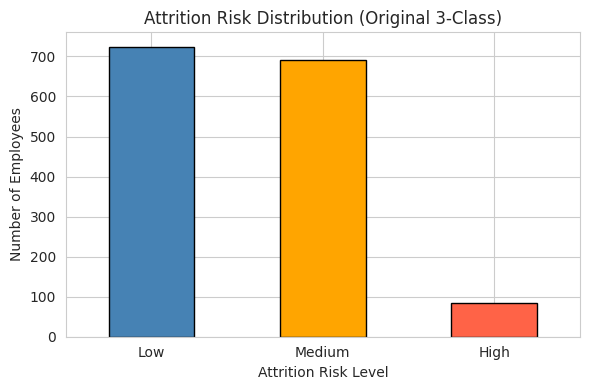

In [ ]:
# Attrition Risk Distribution
plt.figure(figsize=(6, 4))
df['attrition_risk'].value_counts().plot(
    kind='bar', color=['steelblue', 'orange', 'tomato'],
    edgecolor='black')
plt.title('Attrition Risk Distribution (Original 3-Class)')
plt.xlabel('Attrition Risk Level'); plt.ylabel('Number of Employees')
plt.xticks(rotation=0); plt.tight_layout()
plt.savefig('attrition_distribution.png', dpi=150); plt.show()


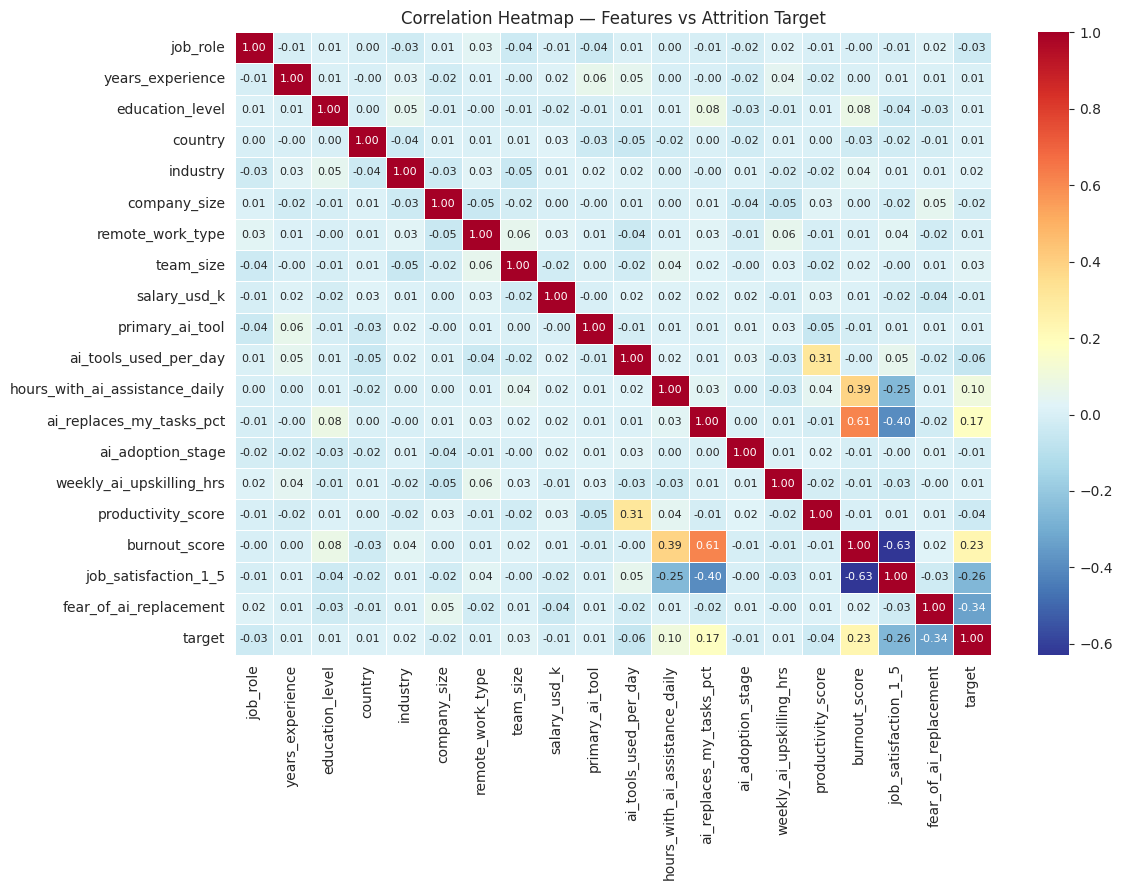

In [ ]:
# Correlation Heatmap (numerical features only)
num_cols = X.select_dtypes(include=[np.number]).columns.tolist() + ['target']
corr_df  = pd.concat([X[X.select_dtypes(include=np.number).columns], y], axis=1)

plt.figure(figsize=(12, 9))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f',
            cmap='RdYlBu_r', linewidths=0.4, annot_kws={'size': 8})
plt.title('Correlation Heatmap — Features vs Attrition Target')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150); plt.show()

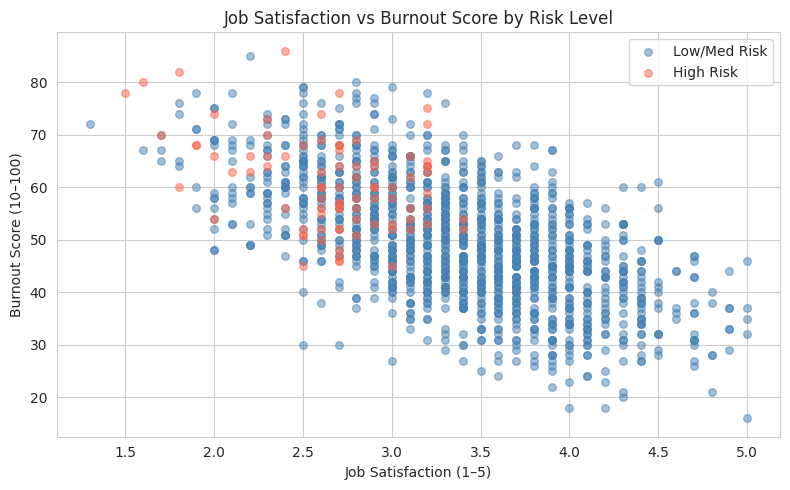

In [ ]:
# Burnout Score vs Job Satisfaction (coloured by risk)
plt.figure(figsize=(8, 5))
colors = {0: 'steelblue', 1: 'tomato'}
for val, label in [(0, 'Low/Med Risk'), (1, 'High Risk')]:
    subset = df[y == val]
    plt.scatter(subset['job_satisfaction_1_5'], subset['burnout_score'],
                alpha=0.5, label=label, color=colors[val], s=30)
plt.xlabel('Job Satisfaction (1–5)')
plt.ylabel('Burnout Score (10–100)')
plt.title('Job Satisfaction vs Burnout Score by Risk Level')
plt.legend(); plt.tight_layout()
plt.savefig('satisfaction_vs_burnout.png', dpi=150); plt.show()

<Figure size 600x400 with 0 Axes>

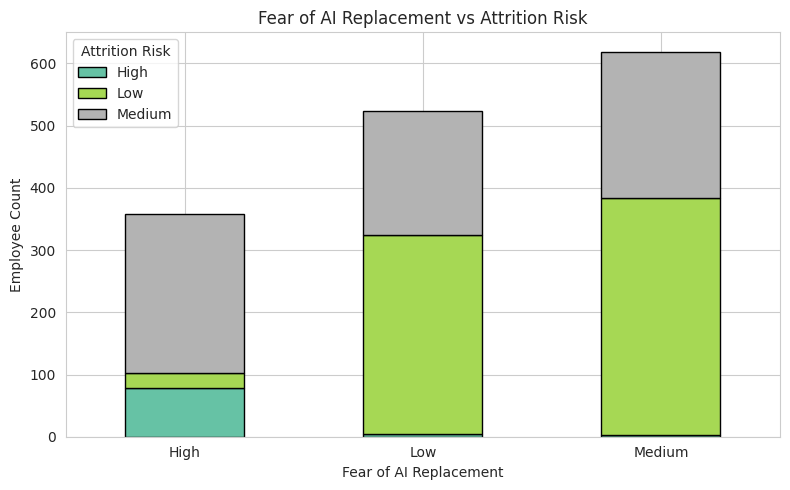

In [ ]:
# Fear of AI Replacement vs Attrition
plt.figure(figsize=(6, 4))
fear_attrition = df.groupby(['fear_of_ai_replacement', 'attrition_risk']).size().unstack()
fear_attrition.plot(kind='bar', stacked=True, colormap='Set2', edgecolor='black')
plt.title('Fear of AI Replacement vs Attrition Risk')
plt.xlabel('Fear of AI Replacement'); plt.ylabel('Employee Count')
plt.xticks(rotation=0); plt.legend(title='Attrition Risk'); plt.tight_layout()
plt.savefig('fear_vs_attrition.png', dpi=150); plt.show()

### Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f'\nTraining samples : {len(X_train)}')
print(f'Testing samples  : {len(X_test)}')
print(f'High-Risk in test: {y_test.sum()} out of {len(y_test)}')


Training samples : 1200
Testing samples  : 300
High-Risk in test: 17 out of 300


In [ ]:
# Only 85 High-Risk employees out of 1500 — very imbalanced!
# SMOTE creates synthetic High-Risk samples to balance training data
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)
print('\nAfter SMOTE (training set):')
print(pd.Series(y_res).value_counts().to_dict())
# Now both classes are balanced for training


After SMOTE (training set):
{0: 1132, 1: 1132}


### Feature Scaling

In [ ]:
# Logistic Regression and SVM are sensitive to feature scale
# StandardScaler transforms each feature to mean=0, std=1
scaler    = StandardScaler()
X_res_sc  = scaler.fit_transform(X_res)    # Fit on training data only
X_test_sc = scaler.transform(X_test)       # Apply same scale to test

### Train Logistics Regression Model

In [ ]:
lr_model = LogisticRegression(max_iter=500, random_state=42)
lr_model.fit(X_res_sc, y_res)

# Predict on test set
y_pred_lr = lr_model.predict(X_test_sc)

print('\n' + '='*55)
print('         LOGISTIC REGRESSION — RESULTS')
print('='*55)
print(classification_report(y_test, y_pred_lr,
      target_names=['Low/Med Risk (0)', 'High Risk (1)']))


         LOGISTIC REGRESSION — RESULTS
                  precision    recall  f1-score   support

Low/Med Risk (0)       0.99      0.94      0.96       283
   High Risk (1)       0.42      0.76      0.54        17

        accuracy                           0.93       300
       macro avg       0.70      0.85      0.75       300
    weighted avg       0.95      0.93      0.94       300



<Figure size 500x400 with 0 Axes>

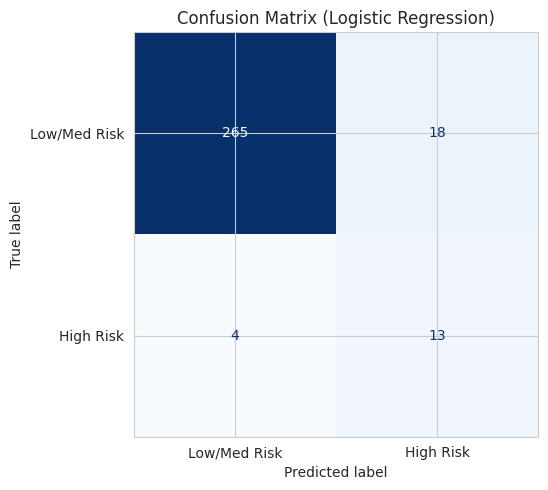

In [ ]:
# Confusion Matrix for Logistic Regression
plt.figure(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=['Low/Med Risk', 'High Risk'],
    colorbar=False, cmap='Blues')
plt.title('Confusion Matrix (Logistic Regression)')
plt.tight_layout()
plt.savefig('cm_logistic_regression.png', dpi=150); plt.show()

### Train SVM Model (Comparison)

In [ ]:
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_res_sc, y_res)
y_pred_svm = svm_model.predict(X_test_sc)

print('\n' + '='*55)
print('          SVM (RBF Kernel) — RESULTS')
print('='*55)
print(classification_report(y_test, y_pred_svm,
      target_names=['Low/Med Risk (0)', 'High Risk (1)']))


          SVM (RBF Kernel) — RESULTS
                  precision    recall  f1-score   support

Low/Med Risk (0)       0.96      0.97      0.96       283
   High Risk (1)       0.40      0.35      0.38        17

        accuracy                           0.93       300
       macro avg       0.68      0.66      0.67       300
    weighted avg       0.93      0.93      0.93       300



<Figure size 500x400 with 0 Axes>

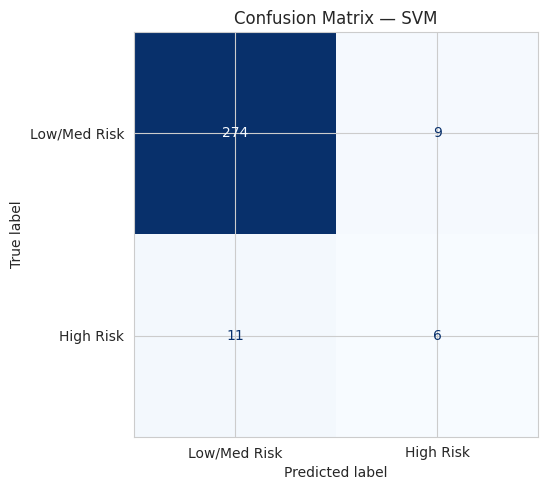

In [ ]:
# Confusion Matrix for SVM
plt.figure(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_svm,
    display_labels=['Low/Med Risk', 'High Risk'],
    colorbar=False, cmap='Blues')
plt.title('Confusion Matrix — SVM')
plt.tight_layout()
plt.savefig('cm_svm.png', dpi=150); plt.show()

### ROC Curves

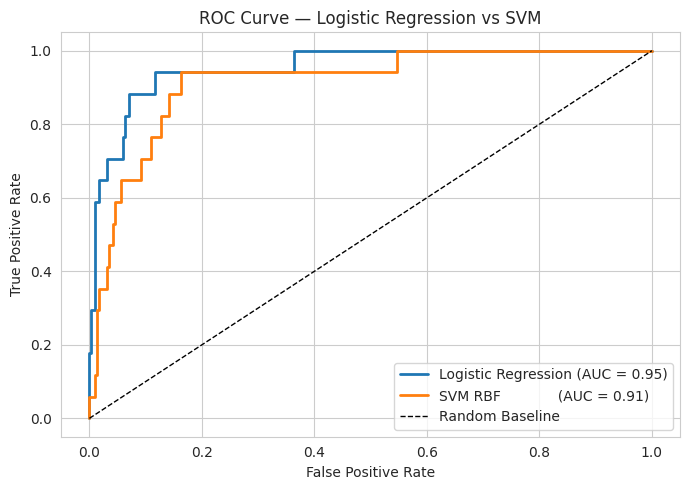


LR  AUC = 0.9539
SVM AUC = 0.9139


In [ ]:
prob_lr  = lr_model.predict_proba(X_test_sc)[:, 1]
prob_svm = svm_model.predict_proba(X_test_sc)[:, 1]

fpr_lr,  tpr_lr,  _ = roc_curve(y_test, prob_lr)
fpr_svm, tpr_svm, _ = roc_curve(y_test, prob_svm)
auc_lr   = auc(fpr_lr, tpr_lr)
auc_svm  = auc(fpr_svm, tpr_svm)

plt.figure(figsize=(7, 5))
plt.plot(fpr_lr,  tpr_lr,  lw=2, label=f'Logistic Regression (AUC = {auc_lr:.2f})')
plt.plot(fpr_svm, tpr_svm, lw=2, label=f'SVM RBF             (AUC = {auc_svm:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Baseline')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression vs SVM')
plt.legend(); plt.tight_layout()
plt.savefig('roc_curve_comparison.png', dpi=150); plt.show()
print(f'\nLR  AUC = {auc_lr:.4f}')
print(f'SVM AUC = {auc_svm:.4f}')

### Feature Importance

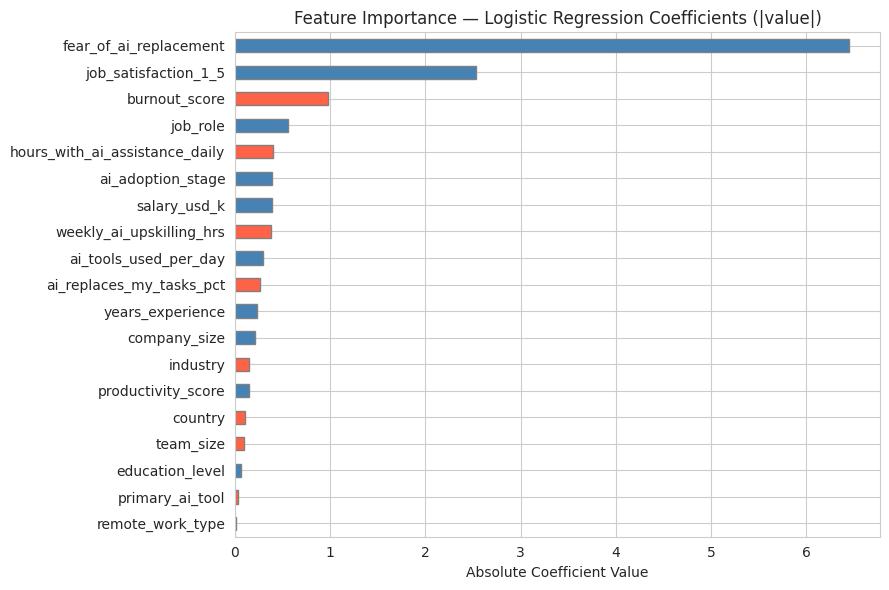

In [ ]:
feature_names = X.columns.tolist()
coef_series   = pd.Series(lr_model.coef_[0], index=feature_names)
coef_sorted   = coef_series.abs().sort_values(ascending=True)

plt.figure(figsize=(9, 6))
colors = ['tomato' if lr_model.coef_[0][feature_names.index(f)] > 0
          else 'steelblue' for f in coef_sorted.index]
coef_sorted.plot(kind='barh', color=colors, edgecolor='gray')
plt.title('Feature Importance — Logistic Regression Coefficients (|value|)')
plt.xlabel('Absolute Coefficient Value')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150); plt.show()

### Predict on New Sample

In [ ]:
# Example: Predict risk for one employee
# (This uses a row from the test set for demonstration)
sample_idx = 5
sample     = X_test_sc[sample_idx:sample_idx+1]
pred_label = lr_model.predict(sample)[0]
pred_prob  = lr_model.predict_proba(sample)[0][1]

print(f'\n--- Sample Prediction (Test Row {sample_idx}) ---')
print(f'Prediction  : {"HIGH RISK" if pred_label == 1 else "LOW/MED RISK"}')
print(f'Probability of High Risk: {pred_prob:.2%}')


--- Sample Prediction (Test Row 5) ---
Prediction  : LOW/MED RISK
Probability of High Risk: 9.51%
